In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7" 

In [3]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import LocalKeyMazeEditorRotateSplitAct
from jaxued.environments.maze.env_editor_sokoban import LocalSokobanMazeEditor, LocalSokobanMazeEditorRotate, LocalSokobanMazeEditorRotateSplitAct
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer, LocalObservedMazeRenderer, SokobanMaze
from jaxued.environments.maze import Level, ObservedLevel, make_level_generator, make_level_sokoban_generator
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

In [4]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_354780/3239372705.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [5]:
env = SokobanMaze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
sample_random_level = make_level_sokoban_generator(env.max_height, env.max_width, 60, 20)
adv_env = LocalSokobanMazeEditorRotateSplitAct(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'], num_agents=1, agent_view_size=5)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8, render_boxes=True)
adv_env_renderer_w_agents = LocalObservedMazeRenderer(env, tile_size=8, render_boxes=True)
env_renderer = MazeRenderer(env, tile_size=8, render_boxes=True)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(0, dtype=jnp.uint8),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_random_init_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 0, 4, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(0, dtype=jnp.uint8),
        observation_map=observation_map.at[agent_pos[1], agent_pos[0]].set(True),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_test_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 1, 2, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_).at[agent_pos[1]+1, agent_pos[0]].set(True),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(config['max_boxes'], dtype=jnp.uint8),
        observation_map=jnp.ones((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

In [6]:
# ADVERSARY INIT
rng, rng_reset, rng_lvl = jax.random.split(rng, 3)
init_adv_obs, init_adv_env_state = adv_env.reset_to_level(rng_reset, sample_random_init_level(rng_lvl), adv_env_params)
#init_adv_obs, init_adv_env_state = adv_env.reset_to_level(rng_reset, random_level, adv_env_params)
adv_state = init_adv_env_state
adv_obs = init_adv_obs

# PROTAGONIST INIT
rng, rng_reset = jax.random.split(rng, 2)
pro_init_obs, pro_init_env_state = env.reset_to_level(rng_reset, adv_state.level, env_params)
pro_env_state = pro_init_env_state
pro_obs = pro_init_obs


In [19]:
adv_obs.action_mask

(Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False, False,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True], dtype=bool),
 Array([ True,  True,  True,  True,  True,  True], dtype=bool))

In [12]:
adv_state.level.max_boxes

Array(2, dtype=uint8)

In [20]:
# EXAMPLE ADV ACTION
action = jnp.array([14, 4])
#action = 17 + 75

rng, _rng = jax.random.split(rng)
adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(_rng, adv_state, action, env_params)
adv_state = adv_next_state

pro_obs, pro_env_state = env.update_state_from_level(adv_state.level, pro_env_state)

In [26]:
# FILL CURRENT SPACE
total_actions = 0
while not (~adv_obs.action_mask[0]).all():
    total_actions += 1
    rng, rng_act, rng_step = jax.random.split(rng, 3)
    action_1 = jax.random.choice(rng_act, jnp.arange(25)[adv_obs.action_mask[0]])
    action_2 = jax.random.choice(rng_act, jnp.arange(6)[adv_obs.action_mask[1]])
    adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(rng_step, adv_state, jnp.array([action_1, action_2]), env_params)
    adv_state = adv_next_state

pro_obs, pro_env_state = env.update_state_from_level(adv_state.level, pro_env_state)

Edit Index: 0
Edit Index: 4
Edit Index: 4
Edit Index: 0
Edit Index: 2
Edit Index: 1
Edit Index: 3
Edit Index: 0
Edit Index: 0
Edit Index: 0
Edit Index: 0
Edit Index: 0
Edit Index: 0
Edit Index: 0
Edit Index: 4
Edit Index: 0
Edit Index: 1
Edit Index: 0
Edit Index: 4
Edit Index: 0
Edit Index: 1
Edit Index: 0
Edit Index: 0
Edit Index: 2
Edit Index: 2
Edit Index: 0
Edit Index: 0


In [36]:
# Add Box
box_location = jnp.array([3, 8], dtype=jnp.uint32)

adv_state = adv_state.replace(level=adv_state.level.replace(
    box_map=adv_state.level.box_map.at[box_location[1], box_location[0]].set(True),
    observation_map=adv_state.level.observation_map.at[box_location[1], box_location[0]].set(True),
))

pro_obs, pro_env_state = env.update_state_from_level(adv_state.level, pro_env_state)

In [33]:
# TAKE PRO STEP

rng, _rng = jax.random.split(rng)
pro_obs, next_state, reward, done, _ = env.step(_rng, pro_env_state, 2, env_params)

next_locs = next_state.env_state.agent_pos.reshape(1, 2)
next_dirs = next_state.env_state.agent_dir.reshape(1)
next_boxes = next_state.env_state.box_map[None, ...]

pro_env_state = next_state
adv_state = adv_state.replace(agent_locs=next_locs, agent_dirs=next_dirs, box_locs=next_boxes)
rng, _rng = jax.random.split(rng)
adv_obs = adv_env.get_finished_obs(_rng, adv_state, jnp.array([True]))


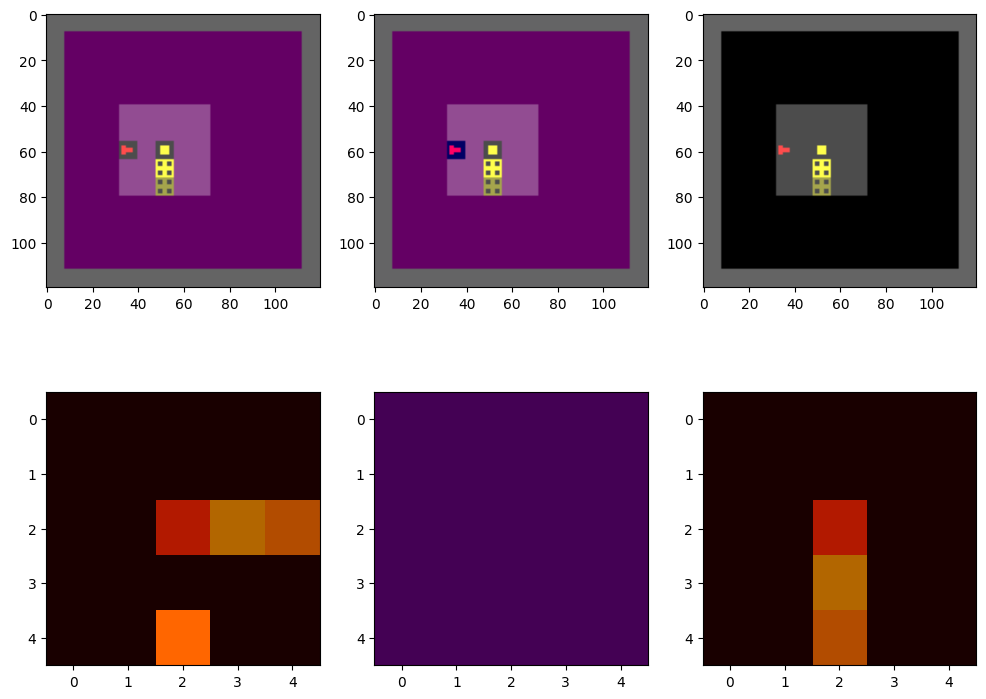

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 9))

adv_state_image = adv_env_renderer.render_state(adv_state.level, env_params)
adv_state_image_w_agents = adv_env_renderer_w_agents.render_state(adv_state, env_params)
pro_state_image = env_renderer.render_state(pro_env_state.env_state, env_params)

axes[0, 0].imshow(adv_state_image)
axes[0, 2].imshow(pro_state_image)
axes[0, 1].imshow(adv_state_image_w_agents)


axes[1, 2].imshow(pro_obs.image)
axes[1, 0].imshow(adv_obs.image)

axes[1, 1].imshow(adv_obs.agent_boxes)
# #axes[4].imshow(adv_obs.observation_map[:, :, 1])

False


Array(4, dtype=int32)

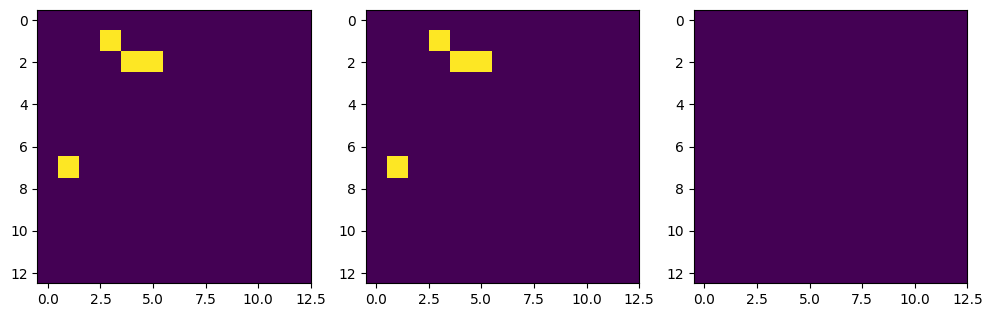

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 9))

test_box_map = jnp.zeros((13, 13)).at[[1, 2, 7, 2], [3, 5, 1, 4]].set(True)
test_box_goal_map = test_box_map#.at[8, 8].set(True)

ax1.imshow(test_box_map)
ax2.imshow(test_box_goal_map)

overlap = jnp.logical_xor(test_box_map, test_box_goal_map)
ax3.imshow(overlap)

print(overlap.any())
jnp.logical_and(test_box_map, test_box_goal_map).sum()

# Random Generation

Text(0.5, 1.0, '0')

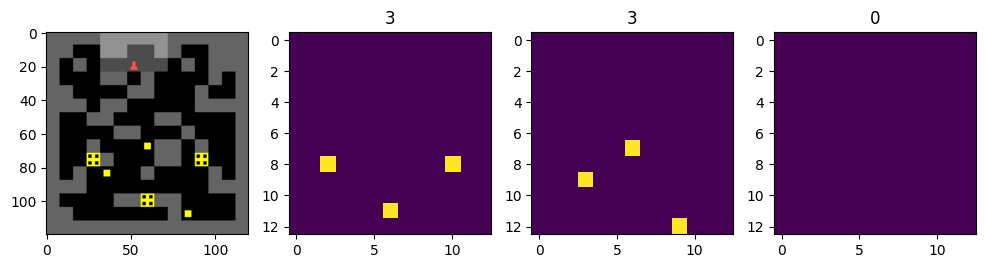

In [21]:
rng, _rng = jax.random.split(rng)
random_level = sample_random_level(rng)

random_level_image = adv_env_renderer.render_level(random_level, env_params)

fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes[0].imshow(random_level_image)

r_box_map = random_level.box_map
axes[1].imshow(r_box_map)
axes[1].set_title(r_box_map.sum())

r_box_goal_map = random_level.box_goal_map
axes[2].imshow(r_box_goal_map)
axes[2].set_title(r_box_goal_map.sum())

overlap = jnp.logical_and(r_box_map, r_box_goal_map)
axes[3].imshow(overlap)
axes[3].set_title(overlap.sum())

# Level Design

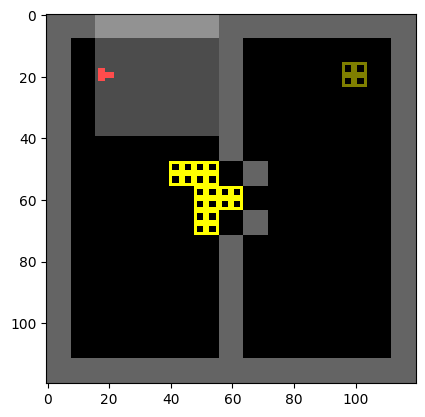

In [ ]:
new_level_str = """
......#......
.>....#....A.
......#......
......#......
......#......
....BB.#.....
.....BB......
.....B.#.....
......#......
......#......
......#......
......#......
......#......
"""

new_level = Level.from_str(new_level_str)
new_level_image = env_renderer.render_level(new_level, env_params)
plt.imshow(new_level_image)

In [17]:

minigrid_levels = [
    "SixteenRooms",
    "SixteenRooms2",
    "Labyrinth",
    "LabyrinthFlipped",
    "Labyrinth2",
    "StandardMaze",
    "StandardMaze2",
    "StandardMaze3",
]

key_minigrid_levels = [
    "SixteenRooms_Key",
    "SixteenRooms2_Key",
    "FourRooms_Key",
    "FourRooms2_Key",
    "FourRooms3_Key",
    "StandardMaze_Key",
    "StandardMaze2_Key",
    "StandardMaze3_Key",
]

sokoban_minigrid_levels = [
    "SixteenRooms_Sokoban",
    "SixteenRooms2_Sokoban",
    "FourRooms_Sokoban",
    "FourRooms2_Sokoban",
    "FourRooms3_Sokoban",
    "Detour_Sokoban",
    "Detour2_Sokoban",
    "MultiStep_Sokoban",
]

sokoban_new_levels = [
    "Sokoban_Jr_1_02",
    "Sokoban_Jr_1_03",
    "Sokoban_Jr_1_04",
    "Sokoban_Jr_1_05",
    "Sokoban_Jr_1_06",
    "Sokoban_Jr_1_07",
    "Sokoban_Jr_1_08",
    "Sokoban_Jr_1_09",
    "Sokoban_Jr_1_12",
    "Sokoban_Jr_1_16"
]

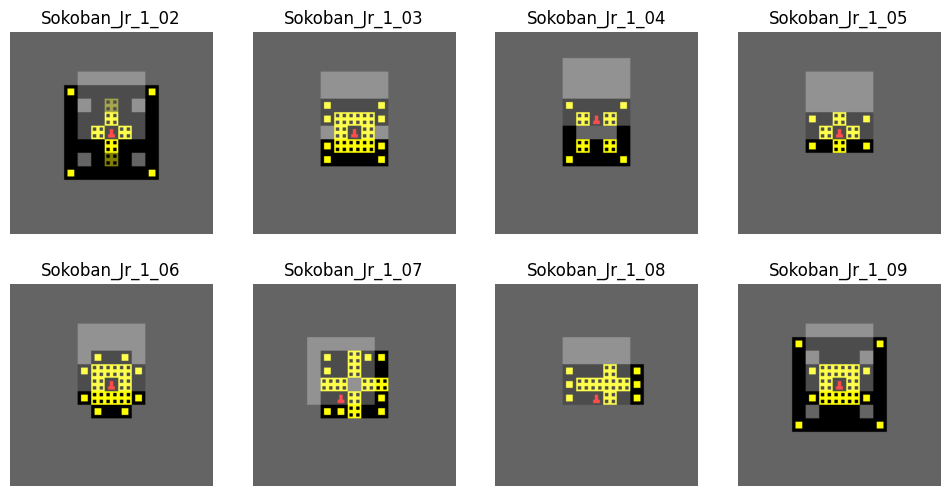

In [18]:
levels = Level.load_prefabs(sokoban_new_levels)
level_images = jax.vmap(env_renderer.render_state, (0, None))(levels, env_params)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.set_title(sokoban_new_levels[i])
    ax.imshow(level_images[i])
    ax.axis('off')

In [24]:
levels.box_map.sum(axis=(1,2))

Array([ 6,  8,  4,  4,  8,  8,  6,  8, 16,  8], dtype=int32)

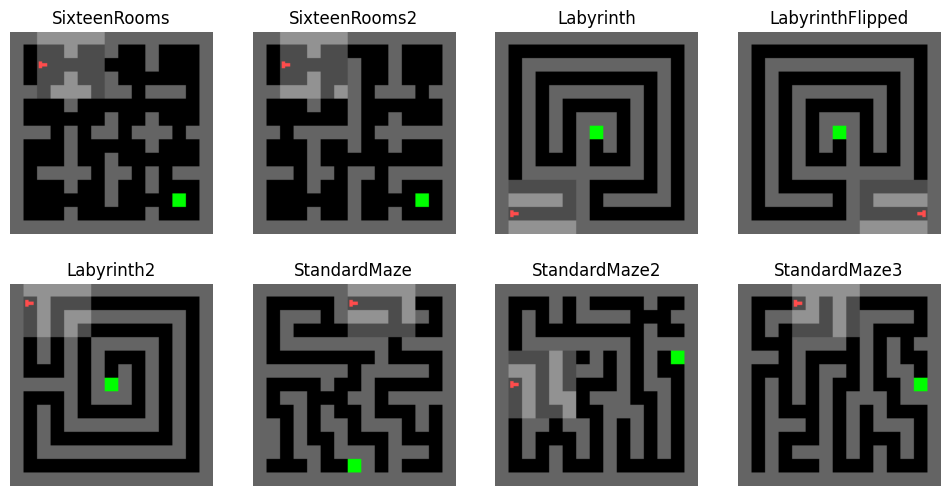

In [27]:
levels = Level.load_prefabs(minigrid_levels)
level_images = jax.vmap(env_renderer.render_state, (0, None))(levels, env_params)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.set_title(minigrid_levels[i])
    ax.imshow(level_images[i])
    ax.axis('off')

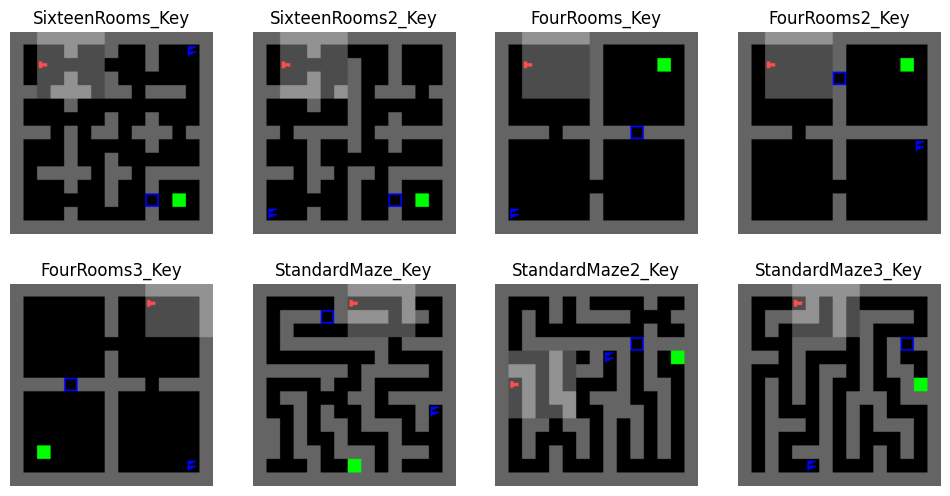

In [28]:
levels = Level.load_prefabs(key_minigrid_levels)
level_images = jax.vmap(env_renderer.render_state, (0, None))(levels, env_params)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.set_title(key_minigrid_levels[i])
    ax.imshow(level_images[i])
    ax.axis('off')